# 3D Map Analysis — RX J1713.7−3946 (H.E.S.S. DL3 DR1, Gammapy 1.3)

**Goal.** Build a 3D map dataset (counts, exposure, PSF, EDISP, FoV background) for the shell-type SNR **RX J1713.7−3946** using **H.E.S.S. DL3 DR1** observations, fit **extended spatial models** (Gaussian and Shell) with a power-law spectrum, and inspect diagnostics (excess & residual maps).

**Workflow**
1. Load H.E.S.S. DR1 and select OBS_IDs for RX J1713.
2. Define a 3D **WCS cube** (FoV & energy axes).
3. Build one **MapDataset per observation**; apply **safe mask** and **FoV background**; then **stack**.
4. Fit **Gaussian** and **Shell** morphologies + **PowerLaw** spectrum.
5. Inspect **excess** and **residual** maps; freeze/unfreeze parameters; export results.

**Requirements**: Gammapy 1.3; `$GAMMAPY_DATA` includes `hess-dl3-dr1`.


In [1]:
import logging
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord, Angle
from regions import CircleSkyRegion

from gammapy.data import DataStore
from gammapy.maps import WcsGeom, MapAxis
from gammapy.datasets import Datasets, MapDataset
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, FoVBackgroundMaker
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    SkyModel,
    PowerLawSpectralModel,
    GaussianSpatialModel,
    ShellSpatialModel,
    FoVBackgroundModel,
    Models
)
from gammapy.estimators import ExcessMapEstimator

import matplotlib.pyplot as plt

# Logging setup
logging.basicConfig()
log = logging.getLogger("rxj1713-3d-hess")
log.setLevel(logging.INFO)

## Load H.E.S.S. DL3 DR1 & select observations

In [2]:
data_store = DataStore.from_dir(f"$GAMMAPY_DATA/hess-dl3-dr1")
data_store.info()

Data store:
HDU index table:
BASE_DIR: /home/jujuba/gammapy-datasets/1.3/hess-dl3-dr1
Rows: 630
OBS_ID: 20136 -- 47829
HDU_TYPE: ['aeff', 'bkg', 'edisp', 'events', 'gti', 'psf']
HDU_CLASS: ['aeff_2d', 'bkg_3d', 'edisp_2d', 'events', 'gti', 'psf_table']


Observation table:
Observatory name: 'N/A'
Number of observations: 105



## Define the target sky position (Galactic frame)

For RX J1713.7−3946 we work in Galactic coordinates, near (l, b) ≈ (347.34°, −0.47°).
This helps when choosing WCS geometry aligned to the Galactic frame later on.


In [3]:
target_position = SkyCoord(l=347.34, b=-0.47, frame='galactic',unit = u.deg)

## Select observations by cone search

We select a **5° radius** circle around the target in the **Galactic** frame.  
This generous radius captures all wobble pointings relevant for RX J1713 in DR1.


In [4]:
selection = dict(
    type="sky_circle",
    frame="galactic",
    lon=347.34*u.deg,
    lat=-0.47*u.deg,
    radius=5*u.deg, #HESS FoV is 5 deg so we set it as that here
)
selected_obs_table = data_store.obs_table.select_observations(selection)

## Peek the selected observation table

This shows the metadata (pointing, zenith, livetime, OBJECT/TARGET_NAME, etc.)  
It’s a good sanity check before we materialize the `Observation` objects.


In [5]:
selected_obs_table

OBS_ID,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,OBJECT,RA_OBJ,DEC_OBJ,OFFSET_OBJ,ONTIME,LIVETIME,DEADC,TSTART,TSTOP,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,TELLIST,QUALITY,MUONEFF,EVENT_COUNT,TARGET_NAME,TARGET_TAG,TARGET_OFFSET,SAFE_ENERGY_LO,SAFE_ENERGY_HI
,deg,deg,deg,deg,deg,deg,deg,,deg,deg,deg,s,s,,s,s,,,,,,,,,,,,deg,TeV,TeV
int64,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float64,float64,bytes10,bytes12,bytes10,bytes12,int64,bytes7,int64,float32,int64,bytes21,bytes14,float32,float32,float32
20326,259.29852,-39.762222,347.74036,-1.0417831,18.712194,71.2878,154.81943,RXJ 1713.7-3946,258.3879,-39.762222,0.6999909,1683.0,1500.009,0.891271,103858277.0,103859960.0,2004-04-17,01:32:21.184,2004-04-17,02:00:24.184,4,"1,2,3,4",0,1.1412385,16880,RX J1713.7-3946,rxj1713,0.7252947,0.23442288,100.0
20327,257.47733,-39.762222,346.91946,0.092252225,16.734882,73.265114,173.0282,RXJ 1713.7-3946,258.3879,-39.762222,0.69996744,1683.0,1497.074,0.889527,103860109.0,103861792.0,2004-04-17,02:02:53.184,2004-04-17,02:30:56.184,4,"1,2,3,4",0,1.1392112,16995,RX J1713.7-3946,rxj1713,0.6746846,0.20417379,100.0
20349,259.29852,-39.762222,347.74036,-1.0417831,16.722466,73.277534,186.67764,RXJ 1713.7-3946,258.3879,-39.762222,0.6999909,1682.0,1494.5023,0.888527,103947504.0,103949186.0,2004-04-18,02:19:28.184,2004-04-18,02:47:30.184,4,"1,2,3,4",0,1.1592567,16141,RX J1713.7-3946,rxj1713,0.7252947,0.20417379,100.0
20350,257.47733,-39.762222,346.91946,0.092252225,18.658506,71.34149,204.89865,RXJ 1713.7-3946,258.3879,-39.762222,0.69996744,1682.0,1497.6545,0.890401,103949330.0,103951012.0,2004-04-18,02:49:54.184,2004-04-18,03:17:56.184,4,"1,2,3,4",0,1.1565586,16081,RX J1713.7-3946,rxj1713,0.6746846,0.23442288,100.0
20396,258.3879,-39.06222,347.8998,-0.062237248,16.931627,73.068375,190.61954,RXJ 1713.7-3946,258.3879,-39.762222,0.70000076,1683.0,1499.001,0.89067197,104120195.0,104121878.0,2004-04-20,02:17:39.184,2004-04-20,02:45:42.184,4,"1,2,3,4",0,1.1642822,16418,RX J1713.7-3946,rxj1713,0.7092343,0.20417379,100.0
20397,258.3879,-40.462223,346.76566,-0.8830993,19.253716,70.746284,207.88188,RXJ 1713.7-3946,258.3879,-39.762222,0.70000076,1682.0,1505.1713,0.89487,104122008.0,104123690.0,2004-04-20,02:47:52.184,2004-04-20,03:15:54.184,4,"1,2,3,4",0,1.1711123,15798,RX J1713.7-3946,rxj1713,0.691681,0.23442288,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20518,258.3879,-39.06222,347.8998,-0.062237248,16.80531,73.194695,171.5077,RXJ 1713.7-3946,258.3879,-39.762222,0.70000076,1682.0,1506.199,0.895481,104463121.0,104464803.0,2004-04-24,01:33:05.184,2004-04-24,02:01:07.184,4,"1,2,3,4",0,1.1684012,14636,RX J1713.7-3946,rxj1713,0.7092343,0.20417379,100.0


## Build the observation list

We now create `Observation` objects for all selected OBS_IDs.


In [6]:
observations = data_store.get_observations(selected_obs_table["OBS_ID"])

INFO:gammapy.data.data_store:Observations selected: 15 out of 15.


In [7]:
for obs in observations:
    print(obs)  # or pprint(obs) for pretty printing

Observation

	obs id            : 20326 
 	tstart            : 53112.06
	tstop             : 53112.08
	duration          : 1683.00 s
	pointing (icrs)   : 259.3 deg, -39.8 deg

	deadtime fraction : 10.9%

Observation

	obs id            : 20327 
 	tstart            : 53112.09
	tstop             : 53112.10
	duration          : 1683.00 s
	pointing (icrs)   : 257.5 deg, -39.8 deg

	deadtime fraction : 11.0%

Observation

	obs id            : 20349 
 	tstart            : 53113.10
	tstop             : 53113.12
	duration          : 1682.00 s
	pointing (icrs)   : 259.3 deg, -39.8 deg

	deadtime fraction : 11.1%

Observation

	obs id            : 20350 
 	tstart            : 53113.12
	tstop             : 53113.14
	duration          : 1682.00 s
	pointing (icrs)   : 257.5 deg, -39.8 deg

	deadtime fraction : 11.0%

Observation

	obs id            : 20396 
 	tstart            : 53115.10
	tstop             : 53115.12
	duration          : 1683.00 s
	pointing (icrs)   : 258.4 deg, -39.1 deg

	deadtim

## Inspect the first observation

We can look at the event distribution and instrument response functions (IRFs)  
for a representative observation (the first in our list).


Observation

	obs id            : 20326 
 	tstart            : 53112.06
	tstop             : 53112.08
	duration          : 1683.00 s
	pointing (icrs)   : 259.3 deg, -39.8 deg

	deadtime fraction : 10.9%



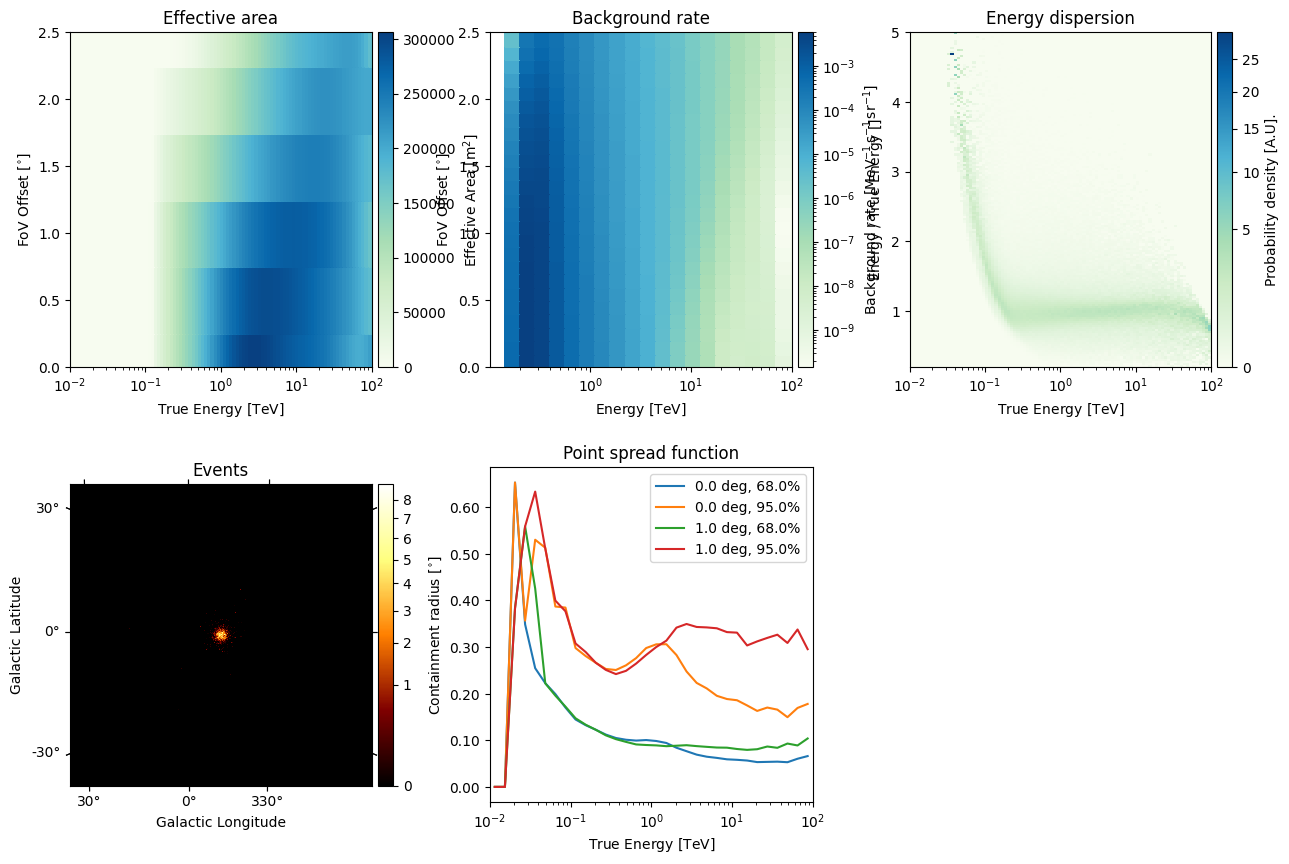

In [8]:
obs = observations[0]
print(obs)
obs.peek()

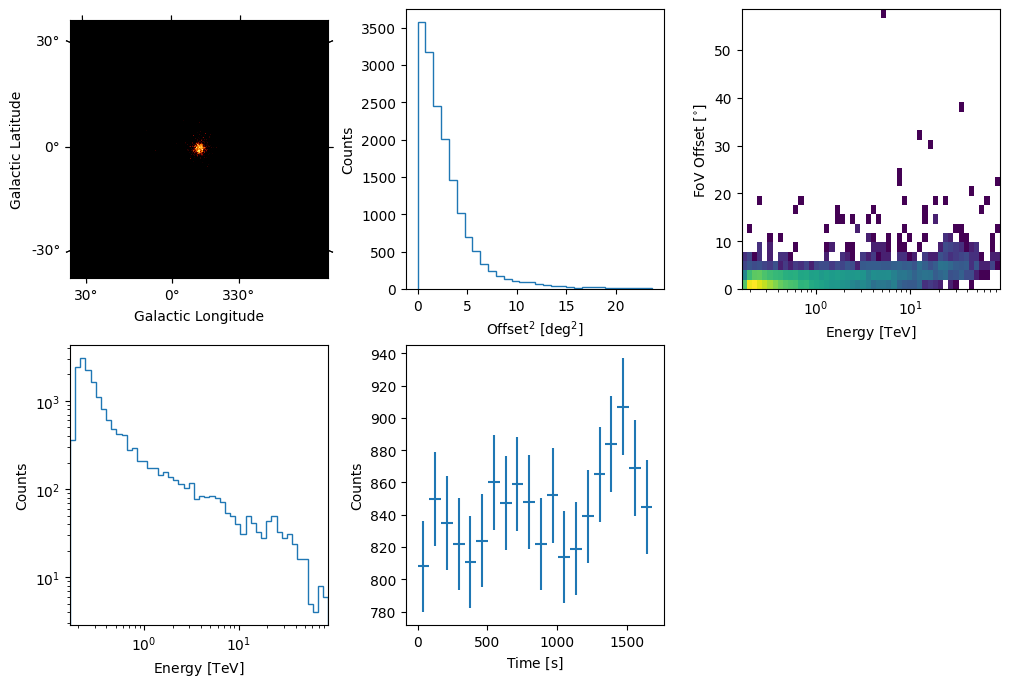

In [9]:
# Quick look at events
events = obs.events
events.peek()

## Inspect IRFs

Each observation comes with IRFs: effective area (AEFF), energy dispersion (EDISP), and PSF.


/home/jujuba/.local/lib/python3.10/site-packages/astropy/units/quantity.py:673: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


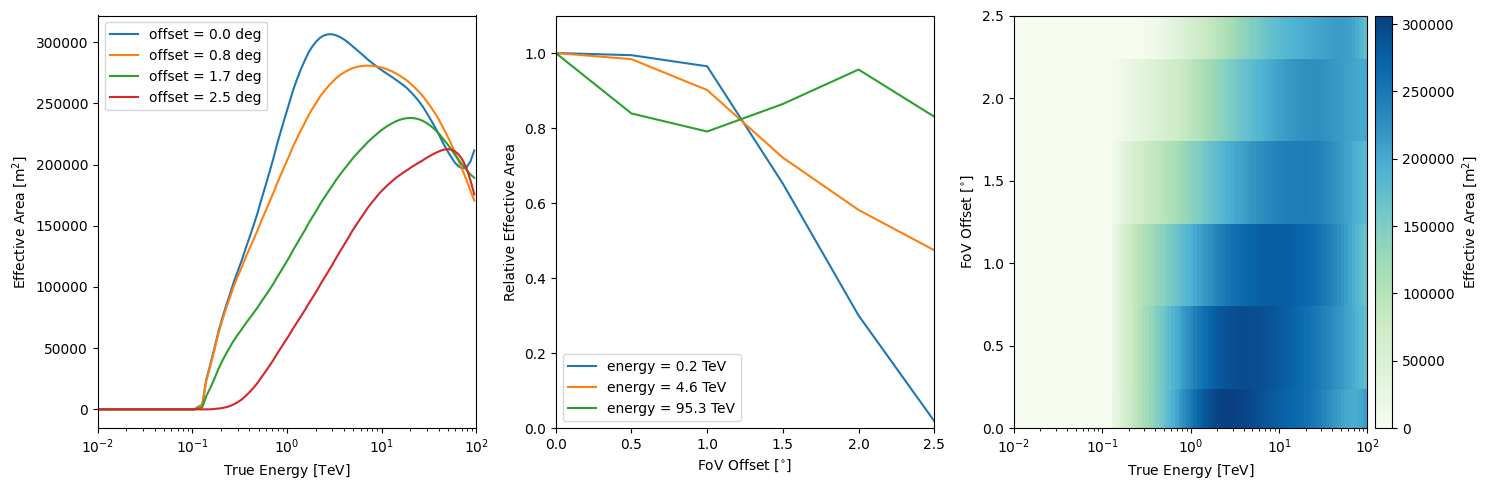

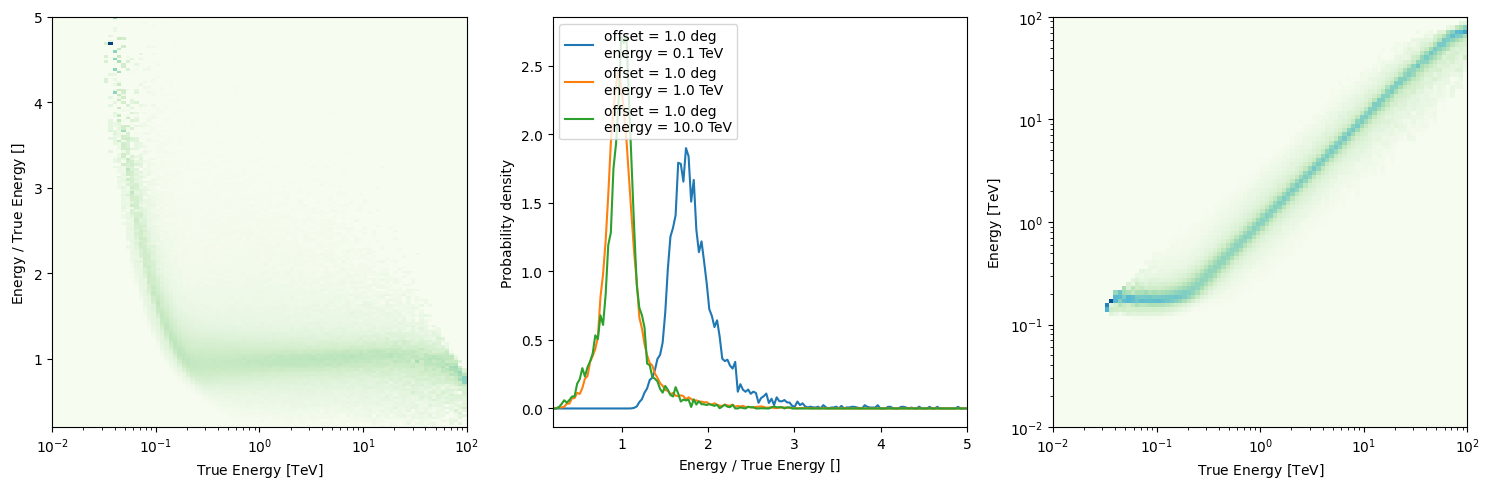

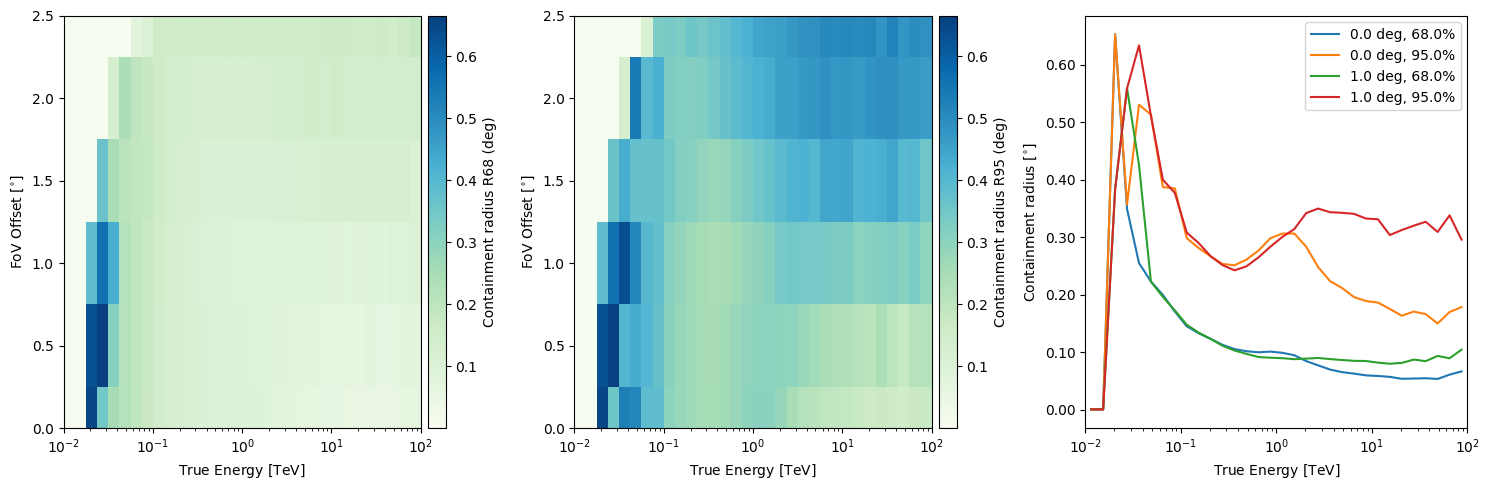

In [10]:
# Effective Area
obs.aeff.peek()

# Energy Dispersion
obs.edisp.peek()

# PSF
obs.psf.peek()

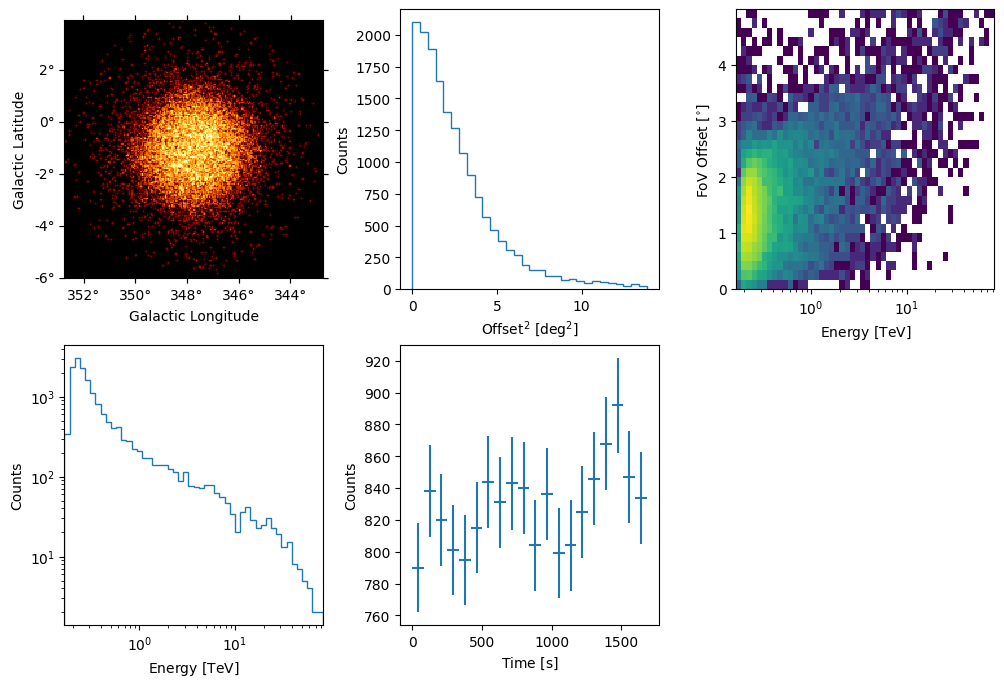

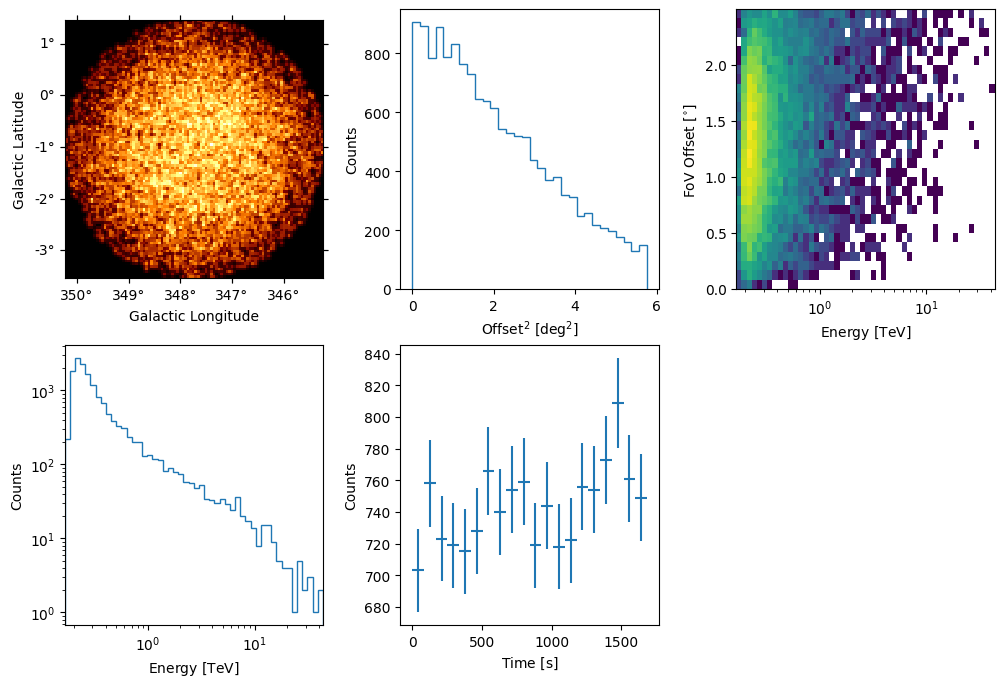

In [11]:
obs.events.select_offset([0, 5] * u.deg).peek()
obs.events.select_offset([0, 2.5] * u.deg).peek()

## Inspect Background model

Check the field-of-view background model provided with the observation.


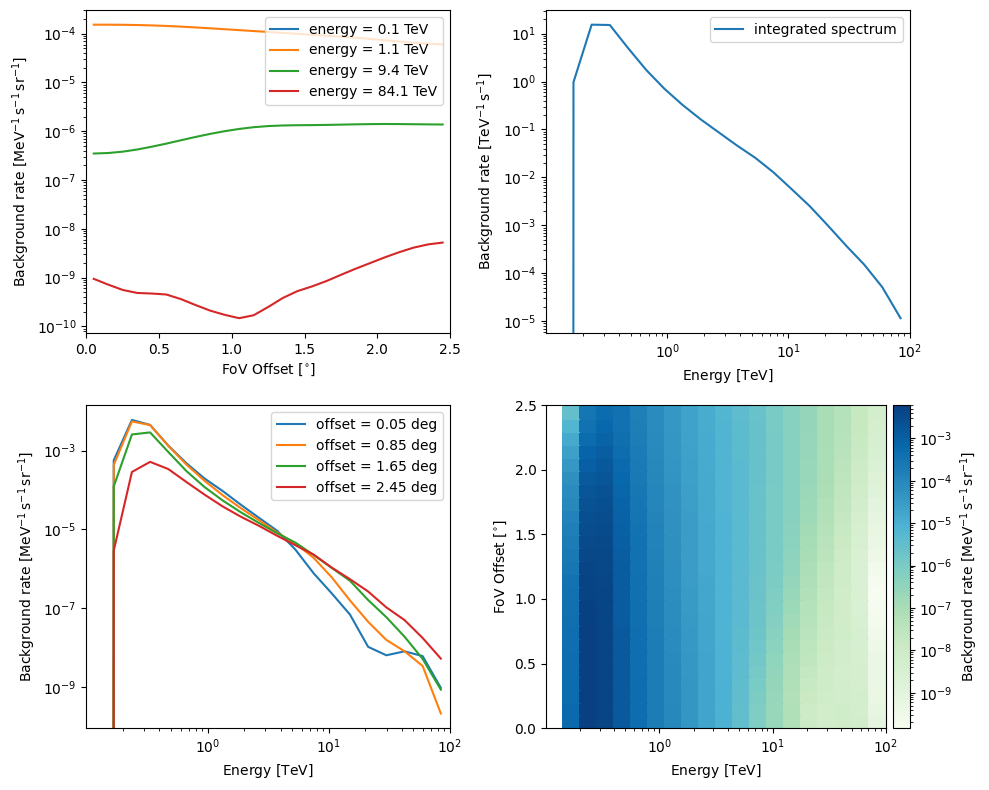

In [12]:
obs.bkg.peek()

## Preparing reduced datasets geometry

We now define the reference geometry for our 3D analysis.  

This geometry specifies:
- the sky projection (centered on our target source),
- the pixel size on the sky (here `0.02 deg`),
- the total width of the field of view (here `6 deg × 6 deg`),
- the energy axis for the reconstructed photon energies.  

In addition, we must also define a *true energy axis* which will be used for evaluating the instrument response functions (IRFs).  
It is important to ensure that the true energy axis is both **wider in energy** and has **more bins** than the reconstructed axis, since the IRFs are defined in true energy.


In [13]:
from gammapy.maps import MapAxis, WcsGeom

# Reconstructed energy axis (what we will bin the counts in)
energy_axis = MapAxis.from_energy_bounds(
    0.3, 10.0, 15, unit="TeV"
)

# Geometry in reconstructed energy (spatial + reconstructed energy axis)
geom = WcsGeom.create(
    skydir=target_position,
    binsz=0.02,         # pixel size in deg
    width=(6, 6),       # total width of the FoV in deg
    frame="galactic",   # coordinates
    axes=[energy_axis], # include reconstructed energy
)

# True energy axis (for IRFs: effective area, PSF, background, energy dispersion)
energy_axis_true = MapAxis.from_energy_bounds(
    0.1, 20.0, 20, unit="TeV", name="energy_true"
)


In [14]:
print(geom)

WcsGeom

	axes       : ['lon', 'lat', 'energy']
	shape      : (300, 300, 15)
	ndim       : 3
	frame      : galactic
	projection : CAR
	center     : 347.3 deg, -0.5 deg
	width      : 6.0 deg x 6.0 deg
	wcs ref    : 347.3 deg, -0.5 deg



## Data reduction — FoV background method (as in the H.E.S.S. tutorial)

Create a blank **accumulator** dataset (`stacked`) that we will fill by looping over observations.


In [15]:
stacked = MapDataset.create(
    geom=geom, energy_axis_true=energy_axis_true, name="rxj-stacked"
)
stacked


## Exclusion mask 

We exclude the main emission region while fitting the FoV background.  
Here we use a **0.7°** radius circle around RX J1713. Adjust if needed.


In [16]:
circle = CircleSkyRegion(center=target_position, radius=0.7 * u.deg)
exclusion_mask = ~geom.region_mask(regions=[circle])  # True = keep for bkg fit

# Quick plot of the mask
ax = exclusion_mask.plot_interactive()



interactive(children=(SelectionSlider(continuous_update=False, description='Select energy:', layout=Layout(wid…

## Makers

- `MapDatasetMaker(selection=['counts','background','psf','edisp','exposure'])`
- `SafeMaskMaker(methods=['offset-max','aeff-max','bkg-peak'], offset_max='2.3 deg')`
- `FoVBackgroundMaker(method='fit', exclusion_mask=exclusion_mask)`

The **background norm** is going to be fitted per observation.


In [17]:
maker = MapDatasetMaker(selection=["counts", "background", "psf", "edisp", "exposure"])
safe_mask_maker = SafeMaskMaker(
    methods=["offset-max", "aeff-max", "bkg-peak"],  
    offset_max="2.3 deg"                             # H.E.S.S. safe FoV radius
)

fov_bkg_maker = FoVBackgroundMaker(method="fit", exclusion_mask=exclusion_mask)

## Run per-observation, fit background, and stack

For each observation:
1) build the per-obs dataset,
2) apply safe mask,
3) **fit the FoV background** (creates a `BackgroundModel` and adjusts its norm),
4) stack into the accumulator `stacked`.

We also print the fitted **background normalization** for each obs.


In [18]:
for obs in observations:
    dataset = maker.run(stacked, obs)           # use our target geometry
    dataset = safe_mask_maker.run(dataset, obs)
    dataset = fov_bkg_maker.run(dataset)        # fits BackgroundModel norm on this dataset

    # Print fitted background normalization (if available)
    try:
        bn = dataset.background_model.spectral_model.norm.value
        print(f"Background norm – OBS_ID {obs.obs_id}: {bn:.2f}")
    except Exception:
        print(f"Background model attached but norm readout differed for OBS_ID {obs.obs_id}")

    # Incremental stack into the accumulator
    stacked.stack(dataset)

stacked


Background norm – OBS_ID 20326: 1.04
Background norm – OBS_ID 20327: 1.06
Background norm – OBS_ID 20349: 1.01
Background norm – OBS_ID 20350: 1.05
Background norm – OBS_ID 20396: 1.01
Background norm – OBS_ID 20397: 1.08
Background norm – OBS_ID 20421: 1.08
Background norm – OBS_ID 20422: 1.01
Background norm – OBS_ID 20517: 1.01
Background norm – OBS_ID 20518: 0.97
Background norm – OBS_ID 20519: 1.00
Background norm – OBS_ID 20521: 1.03
Background norm – OBS_ID 20898: 1.13
Background norm – OBS_ID 20899: 1.04
Background norm – OBS_ID 20900: 1.00


## Data inspection

Before fitting any source model, it is good practice to inspect the content of the dataset.  
We can look at the total counts map, the fitted background map, and the exposure map.  
This helps to verify that the FoV background method worked as expected and that the target source is clearly visible as an excess.


We can save this file so that later you can manipulate it!

```
stacked.write('stacked_MapDataset.fits')
```

We can also `peek` this, just like we did with the observations.

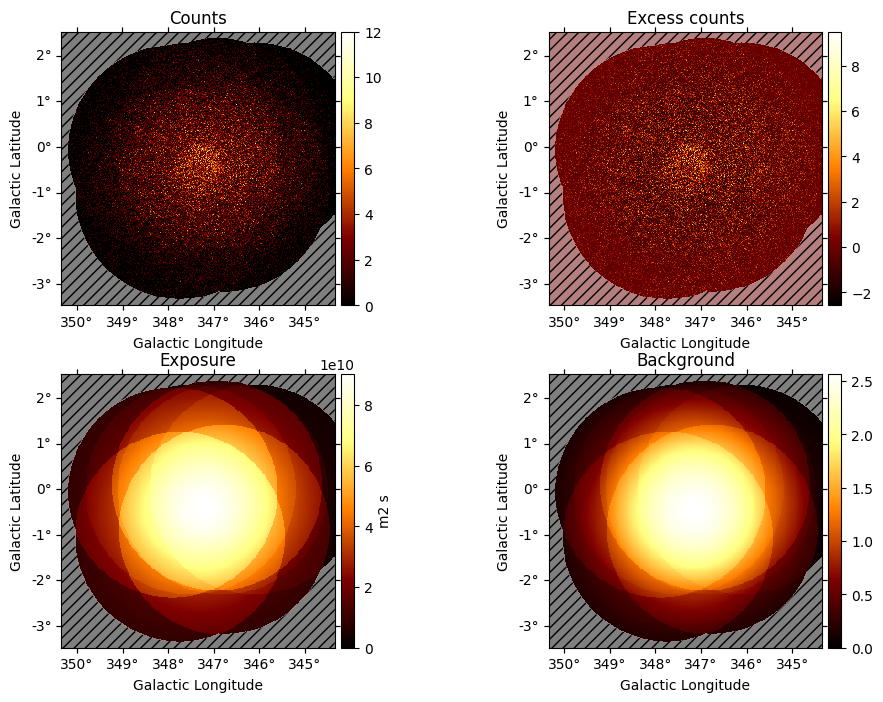

In [19]:
stacked.write('stacked_MapDataset.fits',overwrite=True)
stacked.peek()

## Excess and significance maps (pre-model)

We compare **counts** vs. the **FoV background map** to build:
- **Excess map** = counts − background (integrated in energy)
- **Significance map** (Li & Ma–like, shown as `sqrt_ts`)

We use a **correlation radius** of `0.1 deg` and integrate from **0.8–20 TeV** (stable H.E.S.S. range).


In [20]:
excess_estimator = ExcessMapEstimator(
    correlation_radius="0.1 deg",
    energy_edges=[0.4, 20]*u.TeV
)

excess_result = excess_estimator.run(stacked)

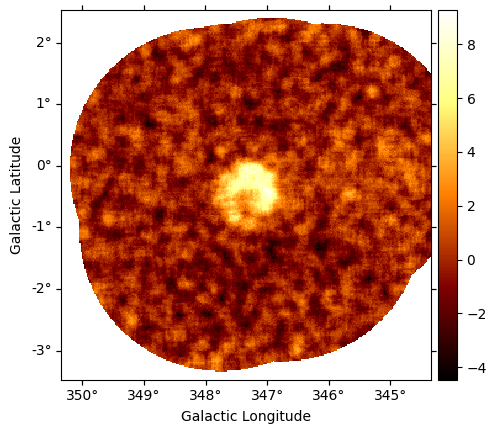

In [21]:
excess_result.sqrt_ts.plot(add_cbar=True)
plt.show()

## 3D modeling — Gaussian spatial model with bounded position

We start from the target position (Galactic) and define a **GaussianSpatialModel**.  
To keep the fit stable, we **limit the source center** inside a **1° box** around the reference position (±0.5° in `l` and `b`).


In [22]:
# Inspect the reference position
target_position

<SkyCoord (Galactic): (l, b) in deg
    (347.34, -0.47)>

In [23]:
spatial_model = GaussianSpatialModel(
    lon_0=target_position.l,
    lat_0=target_position.b,
    sigma=0.3 * u.deg,   # start slightly narrower; will be fit
    frame="galactic",
)

# Limit longitude within ±0.5° of the initial value
spatial_model.lon_0.min = spatial_model.lon_0.value - 0.5
spatial_model.lon_0.max = spatial_model.lon_0.value + 0.5

# Now do the same for latitude
spatial_model.lat_0.min = spatial_model.lat_0.value - 0.5
spatial_model.lat_0.max = spatial_model.lat_0.value + 0.5

spatial_model

## Spectral model and SkyModel

Create a **PowerLawSpectralModel** (index ≈ 2, amplitude ~ 1e-11 cm⁻² s⁻¹ TeV⁻¹ at 1 TeV)  
and combine with the Gaussian spatial model into a `SkyModel`.


In [24]:
spectral_model = PowerLawSpectralModel(
    index=2.0,
    amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
    reference=1 * u.TeV,
)

model_gauss = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="rxj1713_gauss",
)


## Add a background component to the models

The stacked dataset already has a *background map*, but to let the fit adjust it we attach a
`BackgroundModel` linked to the dataset name.


In [25]:
bkg_model = FoVBackgroundModel(dataset_name=stacked.name)

In [26]:
print(bkg_model)

FoVBackgroundModel

  Name                      : rxj-stacked-bkg
  Datasets names            : ['rxj-stacked']
  Spectral model type       : PowerLawNormSpectralModel
  Parameters:
    norm                          :      1.000   +/-    0.00             
    tilt                  (frozen):      0.000                   
    reference             (frozen):      1.000       TeV         




## Attach models to the dataset 

In [27]:
stacked.models = Models([model_gauss, bkg_model])
print(stacked.models)

DatasetModels

Component 0: SkyModel

  Name                      : rxj1713_gauss
  Datasets names            : None
  Spectral model type       : PowerLawSpectralModel
  Spatial  model type       : GaussianSpatialModel
  Temporal model type       : 
  Parameters:
    index                         :      2.000   +/-    0.00             
    amplitude                     :   1.00e-11   +/- 0.0e+00 1 / (cm2 s TeV)
    reference             (frozen):      1.000       TeV         
    lon_0                         :    347.340   +/-    0.00 deg         
    lat_0                         :     -0.470   +/-    0.00 deg         
    sigma                         :      0.300   +/-    0.00 deg         
    e                     (frozen):      0.000                   
    phi                   (frozen):      0.000       deg         

Component 1: FoVBackgroundModel

  Name                      : rxj-stacked-bkg
  Datasets names            : ['rxj-stacked']
  Spectral model type       : PowerLaw

- Let's check the dataset again

MapDataset
----------

  Name                            : rxj-stacked 

  Total counts                    : 74094 
  Total background counts         : 71971.92
  Total excess counts             : 2122.07

  Predicted counts                : 73240.61
  Predicted background counts     : 71971.93
  Predicted excess counts         : 1268.68

  Exposure min                    : 3.58e+05 m2 s
  Exposure max                    : 6.48e+09 m2 s

  Number of total bins            : 1350000 
  Number of fit bins              : 1053870 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : 406422.42

  Number of models                : 2 
  Number of parameters            : 11
  Number of free parameters       : 6

  Component 0: SkyModel
  
    Name                      : rxj1713_gauss
    Datasets names            : None
    Spectral model type       : PowerLawSpectralModel
    Spatial  model type       : GaussianSpatialModel
    Temporal model type       : 
    Paramete

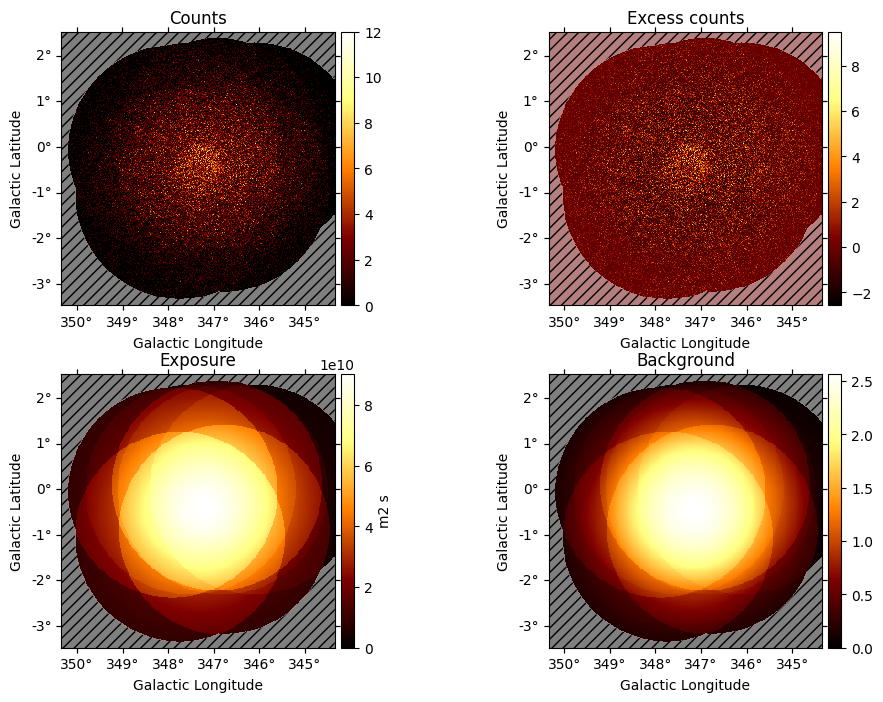

In [28]:
print(stacked)
stacked.peek()

## Fit the current source model together with the FoV background


In [29]:
fit = Fit()
result_1 = fit.run(datasets=[stacked])
print(result_1)

# Parameters (source + background)
stacked.models.to_parameters_table()

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 226
	total stat : 406133.77

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



model,type,name,value,unit,error,min,max,frozen,link,prior
str15,str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
rxj1713_gauss,,index,1.9128e+00,,3.939e-02,nan,nan,False,,
rxj1713_gauss,,amplitude,2.3070e-11,cm-2 s-1 TeV-1,1.145e-12,nan,nan,False,,
rxj1713_gauss,,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
rxj1713_gauss,,lon_0,3.4726e+02,deg,1.751e-02,3.468e+02,3.478e+02,False,,
rxj1713_gauss,,lat_0,-3.7619e-01,deg,1.694e-02,-9.700e-01,3.000e-02,False,,
rxj1713_gauss,,sigma,3.6318e-01,deg,1.299e-02,0.000e+00,nan,False,,
rxj1713_gauss,,e,0.0000e+00,,0.000e+00,0.000e+00,1.000e+00,True,,
rxj1713_gauss,,phi,0.0000e+00,deg,0.000e+00,nan,nan,True,,
rxj-stacked-bkg,,norm,9.8960e-01,,4.105e-03,nan,nan,False,,


## Diagnostics after the fit

Integrated **counts / model (npred) / residuals**, and an **excess map** in 0.8–20 TeV.


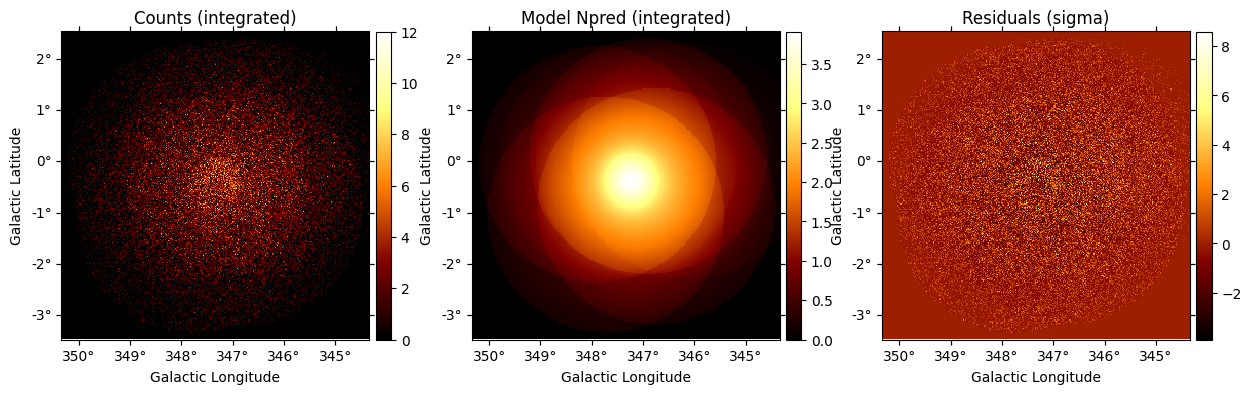

In [30]:
# Integrated maps
counts_int = stacked.counts.sum_over_axes()
model_int  = stacked.npred().sum_over_axes()
resid_int  = stacked.residuals().sum_over_axes()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), subplot_kw={"projection": counts_int.geom.wcs})

counts_int.plot(ax=axes[0], add_cbar=True)
axes[0].set_title("Counts (integrated)")

model_int.plot(ax=axes[1], add_cbar=True)
axes[1].set_title("Model Npred (integrated)")

resid_int.plot(ax=axes[2], add_cbar=True)
axes[2].set_title("Residuals (sigma)")

plt.show()


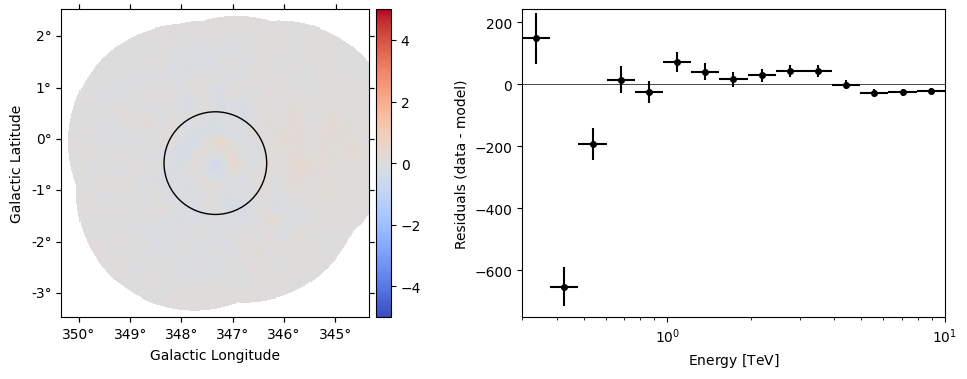

In [31]:
region = CircleSkyRegion(
    center=target_position, radius=1 * u.deg
)
stacked.plot_residuals(kwargs_spectral={"region":region});

## Source detection significance via nested model test 

We quantify **how significant** the source is above background using a **nested hypothesis test**:

- **H₀ (null):** background-only (the source flux is zero).  
- **H₁ (alt):** background + source (amplitude > 0).

We test the **`amplitude`** parameter of the source’s spectral model by fixing it to **0** under H₀ and fitting both models.  
The test returns a **Test Statistic (TS)**, which we convert to a **Gaussian significance** (σ) using `ts_to_sigma`.


In [32]:
from gammapy.modeling.selection import select_nested_models
from gammapy.stats.utils import ts_to_sigma

# --- Freeze spatial parameters of the source model ---
model_gauss.spatial_model.lon_0.frozen = True
model_gauss.spatial_model.lat_0.frozen = True
model_gauss.spatial_model.sigma.frozen = True

# Parameter to test and its null value (H0)
parameters = [model_gauss.spectral_model.amplitude]
null_values = [0.0]   # hipótese nula: sem fluxo da fonte

results = select_nested_models(
    datasets=stacked,
    parameters=parameters,
    null_values=null_values,
    n_sigma=-np.inf,         # compute full TS (no truncation)
)

print(results['ts'])

ts = float(results["ts"])
sigma = ts_to_sigma(ts)
print(f"TS = {ts:.2f}  →  significance = {sigma:.2f} σ")


1068.60121807229
TS = 1068.60  →  significance = 32.69 σ
